Test files with deltas

In [1]:
import h5ify
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from likelihood import get_bilby_likelihood

%load_ext autoreload
%autoreload 2

In [29]:
from pixelpop.models.gwpop_models import trunc_gaussian
from bilby.core.prior import Interped

mu_spin = 1
sigma_spin = 1e-2

cts = jnp.linspace(-1, 1, 1_000)

log_p_ct = trunc_gaussian(cts, mu_spin, sigma_spin, upper=1, lower=-1)
ct_prior = Interped(cts, jnp.exp(log_p_ct), minimum=-1, maximum=1)

samples = ct_prior.sample(1_000_000)

In [30]:
from models import truncnorm
from bilby.core.prior import Interped

mu_spin = 1
sigma_spin = 1e-2

cts = jnp.linspace(-1, 1, 1_000)

p_ct = truncnorm(cts, mu=mu_spin, sigma=sigma_spin, high=1, low=-1)
ct_prior = Interped(cts, p_ct, minimum=-1, maximum=1)

samples_worse = ct_prior.sample(1_000_000)

In [34]:
samples.min()

np.float64(0.9525545533248192)

In [33]:
samples_worse.min()

np.float64(0.9495250254546369)

In [25]:
log_p_ct[-2]

Array(4.6779604, dtype=float32)

In [28]:
cts[-2]

Array(0.997998, dtype=float32)

(1e-05, 100.0)

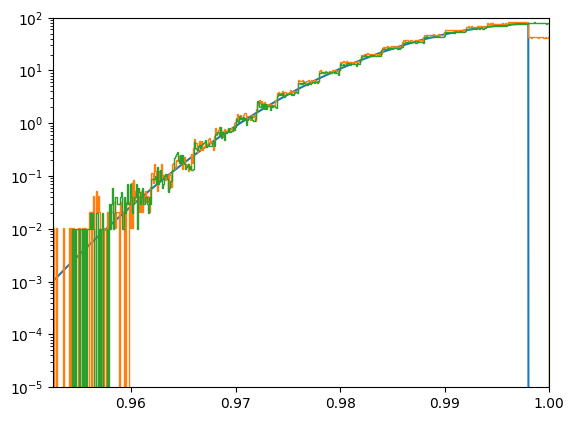

In [36]:
fig, ax = plt.subplots()
ax.plot(cts, jnp.exp(log_p_ct))
ax.hist(samples, histtype='step', bins=500, density=True);
ax.hist(samples_worse, histtype='step', bins=500, density=True)
ax.semilogy();
ax.set_xlim(samples.min(), 1)
ax.set_ylim(1e-5, 1e2)

In [2]:
detectable = h5ify.load('../../data/vt/xp/detectable.hdf5')
ndet = len(detectable['log_prior'])

#detectable['prior'] = jnp.exp(detectable.pop('log_prior'))

In [3]:
allinjs = h5ify.load('../../data/vt/xp/all.hdf5')

In [6]:
allinjs['cos_tilt_1'].min()

np.float64(-0.9974704302134911)

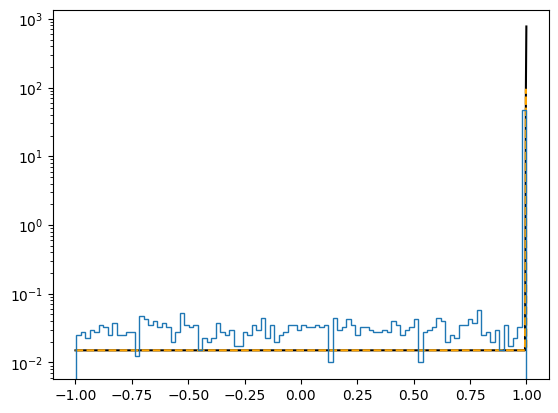

In [14]:
from models import marg_iso_gauss_spin_tilt
from pixelpop.models.gwpop_models import trunc_gaussian

xi_spin = 0.97
mu_spin = 1
sigma_spin = 1e-3

test_tau = jnp.linspace(-1, 1, 1_000)
p_true = marg_iso_gauss_spin_tilt(test_tau, xi_spin, sigma_spin, mu_spin)

log_p_true = jnp.log( (1 - xi_spin) / 2 )
log_p_true = jnp.logaddexp(
    log_p_true, xi_spin * trunc_gaussian(test_tau, mu_spin, sigma_spin, lower=-1, upper=1)
)

fig, ax = plt.subplots()
ax.plot(test_tau, p_true, color='black')
ax.plot(test_tau, jnp.exp(log_p_true), color='orange', linestyle='--')
ax.hist(allinjs['cos_tilt_1'], histtype='step', bins=100, density=True)
ax.set_yscale('log');

In [13]:
jnp.log(p_true) - log_p_true

Array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  

In [31]:
from models import log_powerlaw_redshift
from models import log_iid_spin_mag_truncnorm
from models import log_nid_iso_gauss_tilt
from models import BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth

from pixelpop.models.gwpop_models import PowerlawPlusPeak_MassRatio

def log_model(dataset, parameters):
    if 'lam_2' not in parameters:
        lam_2 = 1 - parameters['lam_1'] - parameters['lam_0']
    else:
        lam_2 = parameters['lam_2']

    log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
        dataset['mass_1'],
        alpha_1=parameters['alpha_1'],
        alpha_2=parameters['alpha_2'],
        mlow_1=parameters['mlow_1'],
        break_mass=parameters['break_mass'],
        delta_m_1=parameters['delta_m_1'],
        lam_fractions=(
            parameters['lam_0'], parameters['lam_1'], lam_2
        ),
        mpp_1=parameters['mpp_1'],
        sigpp_1=parameters['sigpp_1'],
        mpp_2=parameters['mpp_2'],
        sigpp_2=parameters['sigpp_2'],
        mmax=300.0,
        gaussian_mass_maximum=100.0
    )

    log_p_q = PowerlawPlusPeak_MassRatio(
        dataset,
        slope=parameters['beta'],
        minimum=parameters['mlow_1'],
        delta_m=parameters['delta_m_1']
    )

    log_p_z = log_powerlaw_redshift(dataset, parameters)

    log_p_chi = log_iid_spin_mag_truncnorm(dataset, parameters)

    parameters['sigma_spin'] = jnp.exp(parameters['log_sigma_spin'])
    log_p_tau = log_nid_iso_gauss_tilt(dataset, parameters)

    return log_p_m1 + log_p_q + log_p_z + log_p_chi + log_p_tau

In [27]:
import json

with open(f'./parameters/vt-o4a-strong-maxl-sharp-peak.json', 'r') as f:
    truths = json.loads(f.read())
truths.pop('z_max')
truths.pop('lam_2')
truths.pop('mmax')

300.0

(1e-06, 1.0)

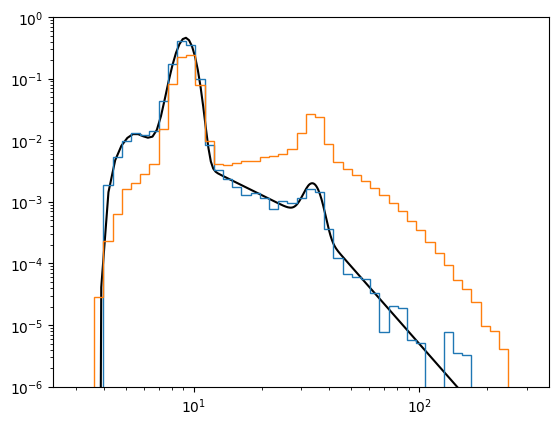

In [6]:
test_m1s = jnp.linspace(3, 300, 1000)

log_p_m1 = BrokenPowerlawPlusTwoPeaks_PrimaryMass_FullSmooth(
    test_m1s,
    alpha_1=truths['alpha_1'],
    alpha_2=truths['alpha_2'],
    mlow_1=truths['mlow_1'],
    break_mass=truths['break_mass'],
    delta_m_1=truths['delta_m_1'],
    lam_fractions=(
        truths['lam_0'], truths['lam_1'], (1 - truths['lam_1'] - truths['lam_0'])
    ),
    mpp_1=truths['mpp_1'],
    sigpp_1=truths['sigpp_1'],
    mpp_2=truths['mpp_2'],
    sigpp_2=truths['sigpp_2'],
    mmax=300.0,
    gaussian_mass_maximum=100.0
)

fig, ax = plt.subplots()
ax.plot(
    test_m1s,
    jnp.exp(log_p_m1),
    linestyle='-',
    color='black'
)
ax.hist(allinjs['mass_1_source'], histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), density=True);
ax.hist(detectable['mass_1_source'], histtype='step', bins=jnp.logspace(jnp.log10(3), jnp.log10(300), 50), density=True);
ax.loglog()
ax.set_ylim(1e-6, 1e0)

In [56]:
nobs = 69 
idxs = jax.random.choice(jax.random.key(42), ndet, shape=(nobs,), replace=False)
idxs = jnp.sort(idxs)

In [57]:
from copy import deepcopy
posteriors = deepcopy(detectable)
posteriors.pop('attrs')
posteriors.pop('total_generated')
posteriors.pop('model')
posteriors.pop('parameters')
posteriors['mass_1'] = posteriors.pop('mass_1_source')
posteriors = {k : v[idxs].reshape(nobs, 1) for k, v in posteriors.items()}

In [58]:
injections = deepcopy(detectable)
injections['mass_1'] = injections.pop('mass_1_source')

In [59]:
maximum_variance = 1

def taper(v):
    """ taper but actually it doesn't do anything! """
    return jnp.nan_to_num(-jnp.inf * (v >= maximum_variance))

likelihood = get_bilby_likelihood(
    log_model,
    posteriors,
    injections,
    taper=taper,
    rate=False
)

In [ ]:
truths['log_sigma_spin'] = 1e-3
likelihood.parameters.update(truths)
likelihood.log_likelihood_ratio()

Array(-3.4028235e+38, dtype=float32)

In [66]:
jnp.exp(-5.646435) * 100

Array(0.353008, dtype=float32, weak_type=True)

In [63]:
likelihood.generate_extra_statistics(truths)

{'ln_lkl': Array(-127.25311, dtype=float32),
 'ln_pdet': Array(-5.646435, dtype=float32),
 'ln_pdet_variance': Array(0.00044854, dtype=float32),
 'pe_variance': Array(0., dtype=float32),
 'variance': Array(2.135483, dtype=float32)}

In [43]:
from bilby.core.prior import ConditionalPriorDict

priors = ConditionalPriorDict('./priors/lvk-lnsigma.prior')
priors['log_sigma_spin'].minimum = -1

In [ ]:
from bilby import run_sampler

outdir = '../../data/runs/vt-xp-delta-test'

result = run_sampler(
    likelihood=likelihood,
    priors=priors,
    outdir=outdir,
    sampler='dynesty',
    sample='acceptance-walk',
    naccept=5,
    nlive=50,
)

14:53 bilby INFO    : Running for label 'label', output will be saved to '../../data/runs/vt-xp-delta-test'


14:53 bilby INFO    : Analysis priors:
14:53 bilby INFO    : alpha_1=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : alpha_2=Uniform(minimum=-4, maximum=12, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : break_mass=Uniform(minimum=20, maximum=50, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : mpp_1=Uniform(minimum=5, maximum=20, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : sigpp_1=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : mpp_2=Uniform(minimum=25, maximum=60, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : sigpp_2=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : delta_m_1=Uniform(minimum=0, maximum=10, name=None, latex_label=None, unit=None, boundary=None)
14:53 bilby INFO    : mlow_1

1it [03:36, ?it/s]


14:54 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 75, 'bound': 'live', 'sample': 'acceptance-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 'grad_args': None, 'grad_kwargs': None, 'compute_jac': False, 'enlarge': None, 'bootstrap': None, 'walks': 100, 'facc': 0.2, 'slices': None, 'fmove': 0.9, 'max_move': 100, 'update_func': None, 'ncdim': None, 'blob': False, 'save_history': False, 'history_filename': None, 'maxiter': None, 'maxcall': None, 'dlogz': 0.1, 'logl_max': inf, 'n_effective': None, 'add_live': True, 'print_progress': True, 'print_func': <bound method Dynesty._print_func of <bilby.core.sampler.dynesty.Dynesty object at 0x7f7b8837f090>>, 'save_bounds': False, 'checkpoint_file': None, 'checkpoint_every': 60, 'resume': F

/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/dynesty/sampler.py:752: RuntimeWarning: overflow encountered in cast
  np.max(self.live_logl) + logvol - logz)
/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/dynesty/utils.py:1350: RuntimeWarning: overflow encountered in cast
  logwt = np.logaddexp(loglstar_new, loglstar) + logdvol  # weight


...

2486it [02:35, 15.93it/s, bound:58 nc:  7 ncall:3.7e+04 eff:6.7% logz-ratio=8.27+/-0.67 dlogz:36.8>0.1]

14:56 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130


14:56 bilby INFO    : Written checkpoint file ../../data/runs/vt-xp-delta-test/label_resume.pickle


SystemExit: 130

/home/noah.wolfe/.conda/envs/seqpop/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [46]:
import json

with open(f'./parameters/vt-o4a-strong-maxl-sharp-peak.json', 'r') as f:
    truths = json.loads(f.read())
truths.pop('z_max')
truths.pop('lam_2')
truths.pop('mmax')

300.0

In [47]:
truths['log_sigma_spin'] = jnp.log(truths.pop('sigma_spin'))

In [54]:
from jax_tqdm import scan_tqdm

@scan_tqdm(len(result.posterior))
def step(carry, x):
    _, parameters = x
    return carry, likelihood.generate_extra_statistics(parameters) 

samples = {k : jnp.array(v) for k, v in result.posterior.items()}

_, extras = jax.lax.scan(step, None, (jnp.arange(len(result.posterior)), samples))

Running for 310 iterations: 100%|██████████| 310/310 [00:00<00:00, 353.42it/s]


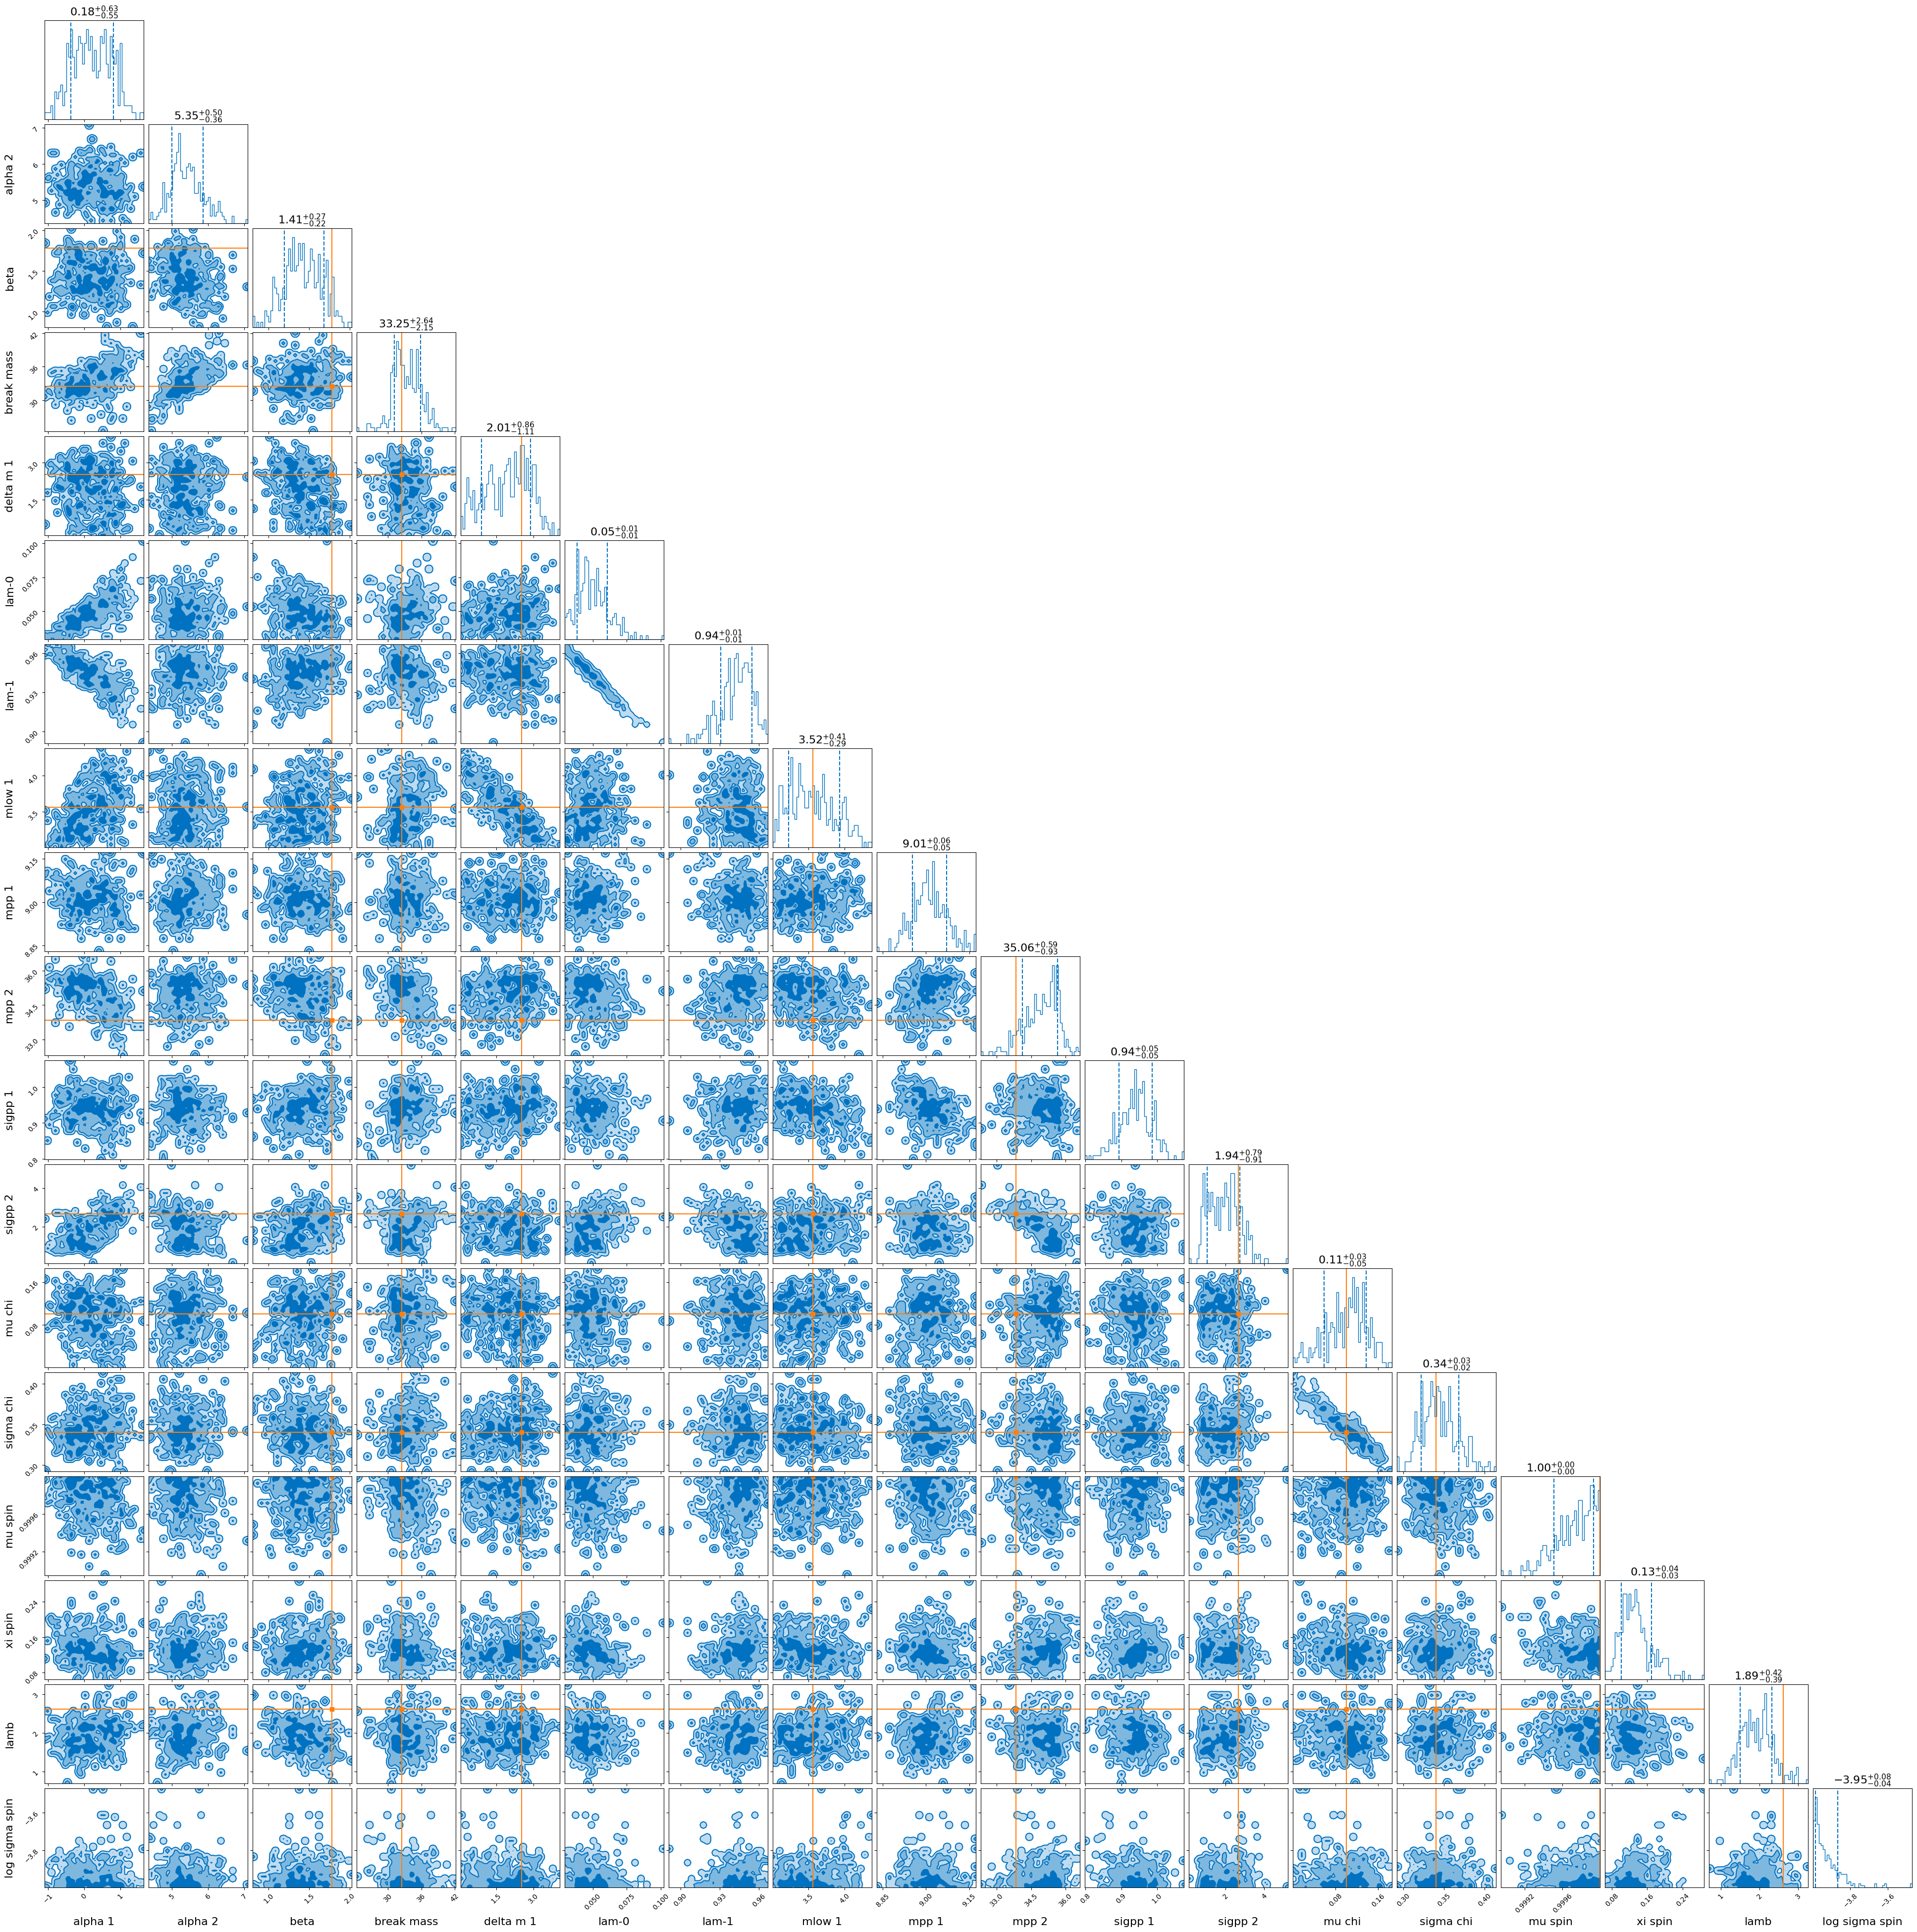

In [48]:
result.plot_corner(truths=truths)